# 2026-08-03 Initial Check: close-to-peak rSFMS

This notebook shows only the resolved star-forming main sequence (rSFMS) for
**close-to-peak galaxies** (infall class 2 from `mauve_master_wiki_newclass.fits`).
MAUVE spaxels and summary trends use distinct blue-adjacent colours for visibility. The comparison
includes the Pessa et al. (2021) 100 pc rSFMS fit and one pooled MAUVE
trend: the mean in log Σ_SFR.


## Setup

The analysis discovers current products below `v3tk_v7.6.8`, keeps only
close-to-peak galaxies, and selects finite HII-region SFR and stellar-mass pixels
with EW(Hα) > 6 Å. `NGC4567_8` inherits an infall class only when both component
galaxies have the same infall class.


In [1]:
# Current further-project products used by the close-to-peak rSFMS analysis.
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 35
Science-ready current further galaxies: 35
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4222, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4424, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4654, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4222,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


,Fit,Method,alpha,beta,N_spaxels,RMSE,R_squared
0,Pessa+21 (published),Published,1.050,-10.630,--,--,--
1,MAUVE all infall stages,OLS,0.803,-8.500,"3,196,545",0.474,0.408
2,MAUVE pre-peak,OLS,0.877,-9.011,"2,018,820",0.481,0.423


Selected full-sample HII spaxels (EW(Ha)>6 A, intrinsic sigma<45 km/s): 3,196,545


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_23752/1238871763.py:357: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


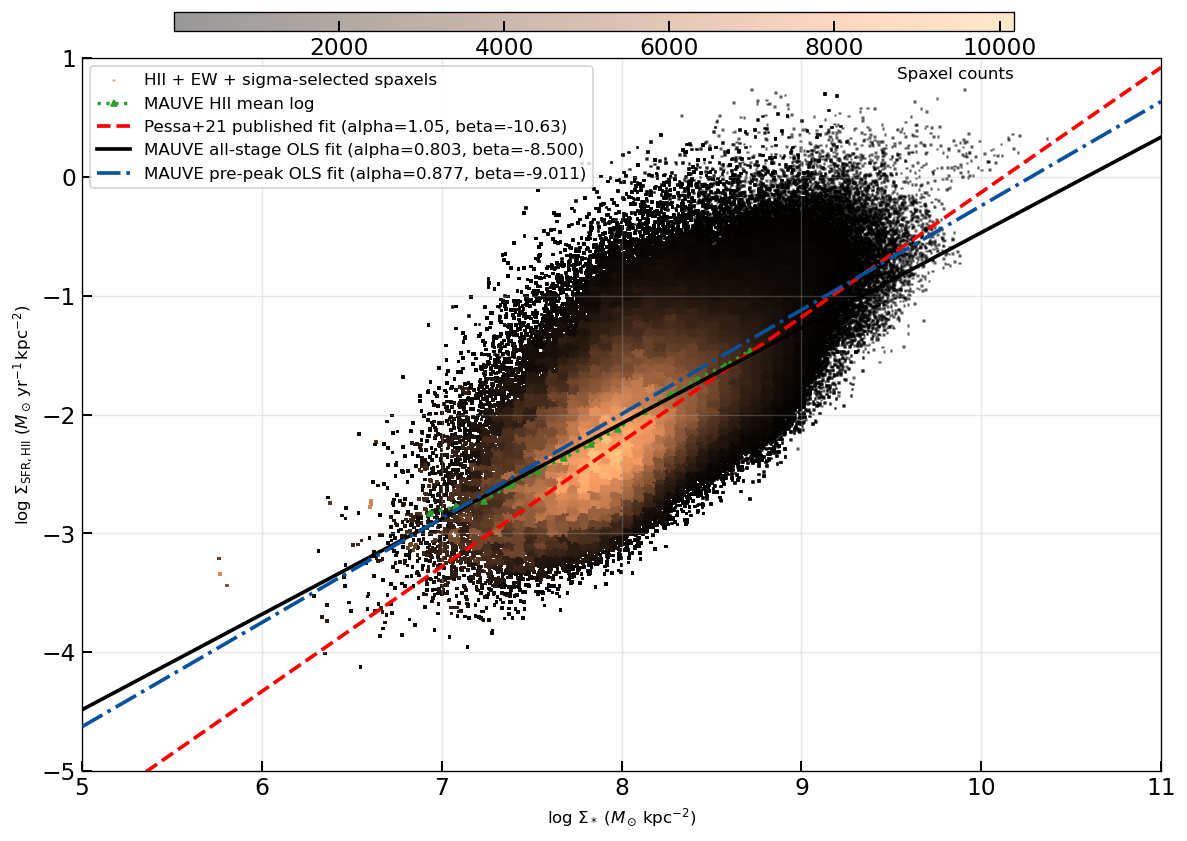

In [4]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS with consistent HII + EW + sigma selection
# Current full further sample, independent of infall stage
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0


def load_selected_rsfms_maps(galaxy):
    """Load and align the four maps needed by the shared rSFMS selection."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy)

    with fits.open(spatial_path) as hdul:
        log_sigma_m = np.asarray(
            hdul["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )
    with fits.open(gas_path) as hdul:
        log_sigma_sfr = np.asarray(
            hdul["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float
        )
        halpha_sigma_obs = np.asarray(hdul["HA6562_SIGMA"].data, dtype=float)
        halpha_sigma_corr = np.asarray(
            hdul["HA6562_SIGMA_CORR"].data, dtype=float
        )
    with fits.open(ew_path) as hdul:
        ew_ha = np.asarray(hdul[EW_HDU].data, dtype=float)

    target_shape = log_sigma_sfr.shape
    log_sigma_m = align_map_to_shape(
        log_sigma_m, target_shape, label=f"{galaxy} stellar mass"
    )
    ew_ha = align_map_to_shape(
        ew_ha, target_shape, label=f"{galaxy} {EW_HDU}"
    )
    halpha_sigma_obs = align_map_to_shape(
        halpha_sigma_obs, target_shape, label=f"{galaxy} HA6562_SIGMA"
    )
    halpha_sigma_corr = align_map_to_shape(
        halpha_sigma_corr, target_shape, label=f"{galaxy} HA6562_SIGMA_CORR"
    )

    sigma2_intrinsic = halpha_sigma_obs**2 - halpha_sigma_corr**2
    halpha_sigma = np.full(target_shape, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    halpha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma


def selected_rsfms_mask(log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma):
    """Select HII spaxels with EW(Halpha)>6 A and intrinsic sigma<45 km/s."""
    return (
        np.isfinite(log_sigma_m)
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
        & np.isfinite(halpha_sigma)
        & (halpha_sigma < HALPHA_SIGMA_MAX)
    )


def binned_rsfms_mean_trend(x, y, *, bin_width, min_pixels):
    """Bin the central 95% in mass and preserve gaps between valid bins."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    x_data = x[central]
    y_data = y[central]

    edges = np.arange(trend_lo, trend_hi, bin_width)
    if edges.size == 0:
        edges = np.asarray([trend_lo])
    if edges[-1] < trend_hi:
        edges = np.append(edges, trend_hi)

    trend_x = []
    mean_log = []
    counts = []
    last_bin = len(edges) - 2
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if index == last_bin:
            in_bin = (x_data >= left) & (x_data <= right)
        else:
            in_bin = (x_data >= left) & (x_data < right)
        count = int(np.count_nonzero(in_bin))
        counts.append(count)
        if count < min_pixels:
            trend_x.append(0.5 * (left + right))
            mean_log.append(np.nan)
            continue

        x_bin = x_data[in_bin]
        y_bin = y_data[in_bin]
        trend_x.append(np.mean(x_bin))
        mean_log.append(np.mean(y_bin))

    return (
        np.asarray(trend_x),
        np.asarray(mean_log),
        np.asarray(counts, dtype=int),
        (trend_lo, trend_hi),
    )



def ols_rsfms_fit(x, y):
    """Fit log Sigma_SFR = alpha * log Sigma_* + beta by OLS."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x_fit = x[finite]
    y_fit = y[finite]
    if x_fit.size < 2:
        raise ValueError("At least two finite spaxels are required for OLS")

    design = np.column_stack((x_fit, np.ones_like(x_fit)))
    alpha, beta = np.linalg.lstsq(design, y_fit, rcond=None)[0]
    residuals = y_fit - (alpha * x_fit + beta)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    return {
        "alpha": float(alpha),
        "beta": float(beta),
        "n_spaxels": int(x_fit.size),
        "rmse": float(np.sqrt(np.mean(residuals**2))),
        "r_squared": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }

# Discover every current further galaxy with mass, HII-SFR, and EW maps.
full_sample_galaxies = PRODUCTS.index[
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
].tolist()


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    full_sample_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
full_sample_infall_class = add_combined_infall_classes(full_sample_infall_class)

all_x_full = []
all_y_full = []
all_x_infall_stages = []
all_y_infall_stages = []
all_x_pre_peak = []
all_y_pre_peak = []
full_sample_galaxy_counts = {}

for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps

    if np.any(selected):
        x_det = log_sigma_m[selected]
        y_det = log_sigma_sfr[selected]
        all_x_full.extend(x_det.ravel())
        all_y_full.extend(y_det.ravel())
        stage = full_sample_infall_class.get(galaxy)
        if stage in (1, 2, 3):
            all_x_infall_stages.extend(x_det.ravel())
            all_y_infall_stages.extend(y_det.ravel())
        if stage == 1:
            all_x_pre_peak.extend(x_det.ravel())
            all_y_pre_peak.extend(y_det.ravel())
        full_sample_galaxy_counts[galaxy] = int(x_det.size)
    else:
        full_sample_galaxy_counts[galaxy] = 0
        print(f"Skipping {galaxy}: no HII+EW+sigma-selected spaxels")

all_x_full = np.asarray(all_x_full, dtype=float)
all_y_full = np.asarray(all_y_full, dtype=float)
if all_x_full.size == 0:
    raise RuntimeError("No valid HII+EW+sigma rSFMS data found.")


all_x_infall_stages = np.asarray(all_x_infall_stages, dtype=float)
all_y_infall_stages = np.asarray(all_y_infall_stages, dtype=float)
all_x_pre_peak = np.asarray(all_x_pre_peak, dtype=float)
all_y_pre_peak = np.asarray(all_y_pre_peak, dtype=float)
if all_x_infall_stages.size == 0:
    raise RuntimeError("No valid class 1-3 spaxels found for the all-stage OLS fit.")
if all_x_pre_peak.size == 0:
    raise RuntimeError("No valid pre-peak spaxels found for the OLS fit.")

mauve_all_fit = ols_rsfms_fit(all_x_infall_stages, all_y_infall_stages)
mauve_pre_peak_fit = ols_rsfms_fit(all_x_pre_peak, all_y_pre_peak)
mauve_all_alpha = mauve_all_fit["alpha"]
mauve_all_intercept = mauve_all_fit["beta"]
mauve_pre_peak_alpha = mauve_pre_peak_fit["alpha"]
mauve_pre_peak_intercept = mauve_pre_peak_fit["beta"]

pessa_alpha_full = 1.05
pessa_intercept_full = -10.63
rsfms_fit_results = pd.DataFrame(
    [
        {
            "Fit": "Pessa+21 (published)",
            "Method": "Published",
            "alpha": pessa_alpha_full,
            "beta": pessa_intercept_full,
            "N_spaxels": "--",
            "RMSE": np.nan,
            "R_squared": np.nan,
        },
        {
            "Fit": "MAUVE all infall stages",
            "Method": "OLS",
            "alpha": mauve_all_alpha,
            "beta": mauve_all_intercept,
            "N_spaxels": f"{mauve_all_fit['n_spaxels']:,}",
            "RMSE": mauve_all_fit["rmse"],
            "R_squared": mauve_all_fit["r_squared"],
        },
        {
            "Fit": "MAUVE pre-peak",
            "Method": "OLS",
            "alpha": mauve_pre_peak_alpha,
            "beta": mauve_pre_peak_intercept,
            "N_spaxels": f"{mauve_pre_peak_fit['n_spaxels']:,}",
            "RMSE": mauve_pre_peak_fit["rmse"],
            "R_squared": mauve_pre_peak_fit["r_squared"],
        },
    ]
)
display(
    rsfms_fit_results.style.format(
        {"alpha": "{:.3f}", "beta": "{:.3f}", "RMSE": "{:.3f}", "R_squared": "{:.3f}"},
        na_rep="--",
    )
)


print(
    "Selected full-sample HII spaxels "
    f"(EW(Ha)>{EW_MIN:g} A, intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s): "
    f"{all_y_full.size:,}"
)

fig, ax_combined = plt.subplots(figsize=(10, 8))

# Density-colored scatter of all selected pixels.
H, xedges, yedges = np.histogram2d(
    all_x_full,
    all_y_full,
    bins=100,
    range=[[5, 11], [-5, 1]],
)
x_idx = np.clip(np.digitize(all_x_full, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y_full, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x_full,
    all_y_full,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="HII + EW + sigma-selected spaxels",
    zorder=1,
)

# The mean-log trend uses exact percentile bounds. NaNs preserve gaps where a bin
# contains fewer than 50 selected pixels, preventing unsupported line segments.
(
    trend_x_full,
    mean_log_hii_full,
    trend_counts_full,
    (trend_lo_full, trend_hi_full),
) = binned_rsfms_mean_trend(
    all_x_full,
    all_y_full,
    bin_width=0.15,
    min_pixels=50,
)
bin_width = 0.15
min_pixels_per_bin = 50

ax_combined.plot(
    trend_x_full,
    mean_log_hii_full,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE HII mean log",
    zorder=7,
)


x_rsfms_fit_full = np.linspace(5, 11, 200)
ax_combined.plot(
    x_rsfms_fit_full,
    pessa_alpha_full * x_rsfms_fit_full + pessa_intercept_full,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 published fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_all_alpha * x_rsfms_fit_full + mauve_all_intercept,
    color="black",
    linestyle="-",
    linewidth=2.2,
    label=(
        f"MAUVE all-stage OLS fit "
        f"(alpha={mauve_all_alpha:.3f}, beta={mauve_all_intercept:.3f})"
    ),
    zorder=9,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_pre_peak_alpha * x_rsfms_fit_full + mauve_pre_peak_intercept,
    color="#08519C",
    linestyle="-.",
    linewidth=2.2,
    label=(
        f"MAUVE pre-peak OLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
    zorder=10,
)

ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}}\; "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
)
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(
    loc="upper left", ncol=1, frameon=True, framealpha=0.85
)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")
plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.pdf", bbox_inches="tight")
plt.show()


## Close-to-peak resolved star-forming main sequence

Pale cyan-blue points are the pooled close-to-peak HII-region spaxels. The summary
curve follows the detected-pixel definition in cell 25 of
`20260412_Plot_Paper_1_referee.ipynb`: the mean log Σ_SFR in 0.15 dex
stellar-mass bins. The reference curve is the MAUVE pre-peak OLS fit measured in cell 6
with the same selected-spaxel definition.


  NGC4298: 144,157 close-to-peak selected HII spaxels
  NGC4302: 27,304 close-to-peak selected HII spaxels
  NGC4330: 35,688 close-to-peak selected HII spaxels
  NGC4388: 17,663 close-to-peak selected HII spaxels
  NGC4402: 46,769 close-to-peak selected HII spaxels
  NGC4424: 8,994 close-to-peak selected HII spaxels
  NGC4501: 251,936 close-to-peak selected HII spaxels
  NGC4522: 48,946 close-to-peak selected HII spaxels
  NGC4654: 345,036 close-to-peak selected HII spaxels
  NGC4694: 1,058 close-to-peak selected HII spaxels


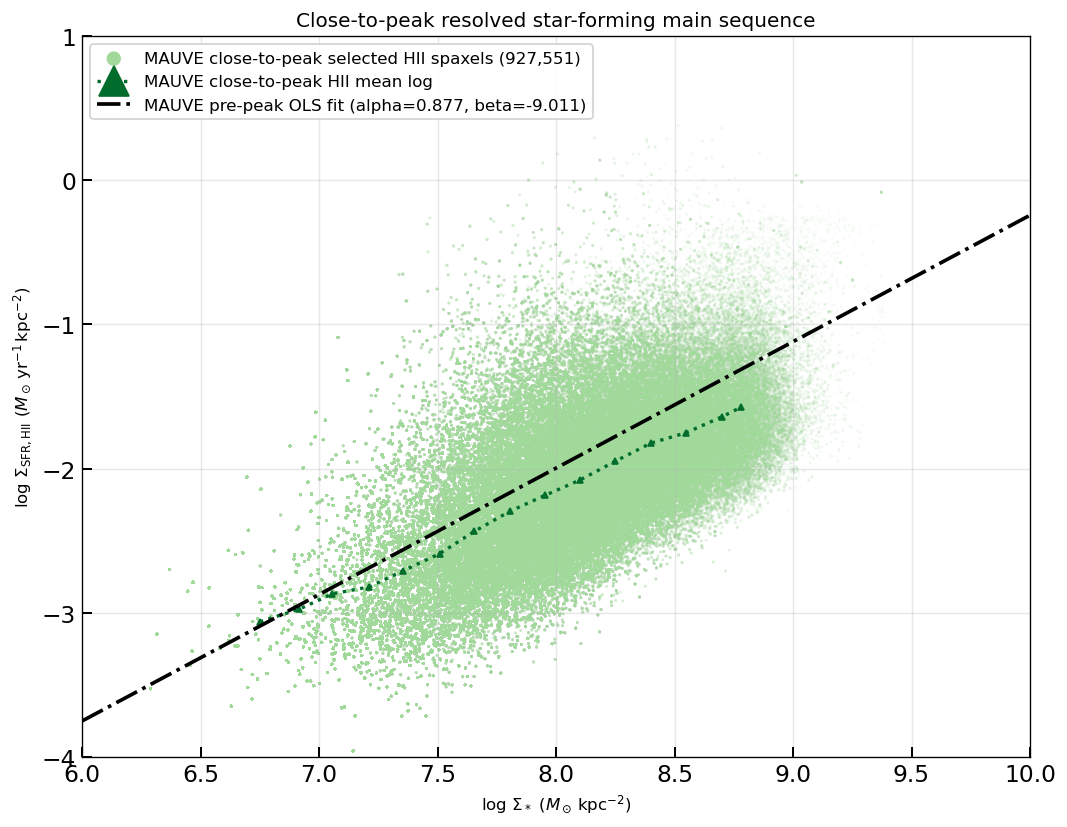


Close-to-peak rSFMS sample:
  Spaxels: 927,551
  Galaxies: NGC4298, NGC4302, NGC4330, NGC4388, NGC4402, NGC4424, NGC4501, NGC4522, NGC4654, NGC4694
  EW(Ha) cut: > 6 A
  Intrinsic Halpha dispersion cut: < 45 km/s
  Trend mass range (central 95%): 6.678 to 8.786


In [5]:
# Close-to-peak rSFMS with the shared HII + EW + intrinsic-sigma selection.
RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.15
RSFMS_MIN_PIXELS_PER_BIN = 50
RSFMS_STAGE = 2
RSFMS_SCATTER_COLOR = "#A1D99B"
RSFMS_CONTOUR_COLOR = "#238B45"
RSFMS_MEAN_LOG_COLOR = "#006D2C"


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    rsfms_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
rsfms_infall_class = add_combined_infall_classes(rsfms_infall_class)

rsfms_ready = (
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
)
rsfms_galaxies = PRODUCTS.index[rsfms_ready].tolist()
all_log_sigma_m = []
all_log_sigma_sfr = []
included_rsfms_galaxies = []

print("Collecting close-to-peak HII+EW+sigma-selected spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage != RSFMS_STAGE:
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} close-to-peak selected HII spaxels")
    if n_spaxels == 0:
        continue
    included_rsfms_galaxies.append(galaxy)
    all_log_sigma_m.extend(log_sigma_m[selected].ravel())
    all_log_sigma_sfr.extend(log_sigma_sfr[selected].ravel())

all_log_sigma_m = np.asarray(all_log_sigma_m, dtype=float)
all_log_sigma_sfr = np.asarray(all_log_sigma_sfr, dtype=float)
if all_log_sigma_m.size == 0:
    raise RuntimeError("No valid close-to-peak HII+EW+sigma-selected spaxels found.")

# The mean-log trend uses exact central-95% bounds; under-populated bins remain
# as NaN gaps so the plotted curve never bridges unsupported mass intervals.
(
    trend_x,
    mean_log_hii,
    trend_counts,
    (trend_lo, trend_hi),
) = binned_rsfms_mean_trend(
    all_log_sigma_m,
    all_log_sigma_sfr,
    bin_width=RSFMS_BIN_WIDTH,
    min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    all_log_sigma_m,
    all_log_sigma_sfr,
    s=3,
    alpha=0.08,
    color=RSFMS_SCATTER_COLOR,
    edgecolors="none",
    rasterized=True,
    label=f"MAUVE close-to-peak selected HII spaxels ({all_log_sigma_m.size:,})",
    zorder=1,
)
ax.plot(
    trend_x,
    mean_log_hii,
    color=RSFMS_MEAN_LOG_COLOR,
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE close-to-peak HII mean log",
    zorder=7,
)

x_pre_peak_fit = np.linspace(*RSFMS_XRANGE, 200)
y_pre_peak_fit = mauve_pre_peak_alpha * x_pre_peak_fit + mauve_pre_peak_intercept
ax.plot(
    x_pre_peak_fit,
    y_pre_peak_fit,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    label=(
        f"MAUVE pre-peak OLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
    zorder=8,
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Close-to-peak resolved star-forming main sequence",
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="upper left", framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_close_to_peak_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_close_to_peak_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nClose-to-peak rSFMS sample:")
print(f"  Spaxels: {all_log_sigma_m.size:,}")
print(f"  Galaxies: {', '.join(included_rsfms_galaxies)}")
print(f"  EW(Ha) cut: > {EW_MIN:g} A")
print(f"  Intrinsic Halpha dispersion cut: < {HALPHA_SIGMA_MAX:g} km/s")
print(f"  Trend mass range (central 95%): {trend_lo:.3f} to {trend_hi:.3f}")


  IC3392: 13,897 Post-peak selected spaxels
  NGC4064: 3,273 Post-peak selected spaxels
  NGC4189: 96,364 Pre-peak selected spaxels
  NGC4192: 144,333 Pre-peak selected spaxels
  NGC4222: 42,249 Pre-peak selected spaxels
  NGC4254: 661,963 Pre-peak selected spaxels
  NGC4293: 471 Post-peak selected spaxels
  NGC4294: 68,833 Pre-peak selected spaxels
  NGC4321: 454,131 Pre-peak selected spaxels
  NGC4351: 30,711 Pre-peak selected spaxels
  NGC4380: 64,097 Post-peak selected spaxels
  NGC4383: 25,212 Pre-peak selected spaxels
  NGC4394: 31,915 Post-peak selected spaxels
  NGC4396: 85,378 Pre-peak selected spaxels
  NGC4405: 13,569 Post-peak selected spaxels
  NGC4419: 5,763 Post-peak selected spaxels
  NGC4450: 17,186 Post-peak selected spaxels
  NGC4457: 5,604 Post-peak selected spaxels
  NGC4535: 187,113 Pre-peak selected spaxels
  NGC4567_8: 222,533 Pre-peak selected spaxels
  NGC4569: 45,477 Post-peak selected spaxels
  NGC4580: 22,438 Post-peak selected spaxels
  NGC4606: 1,752 Post

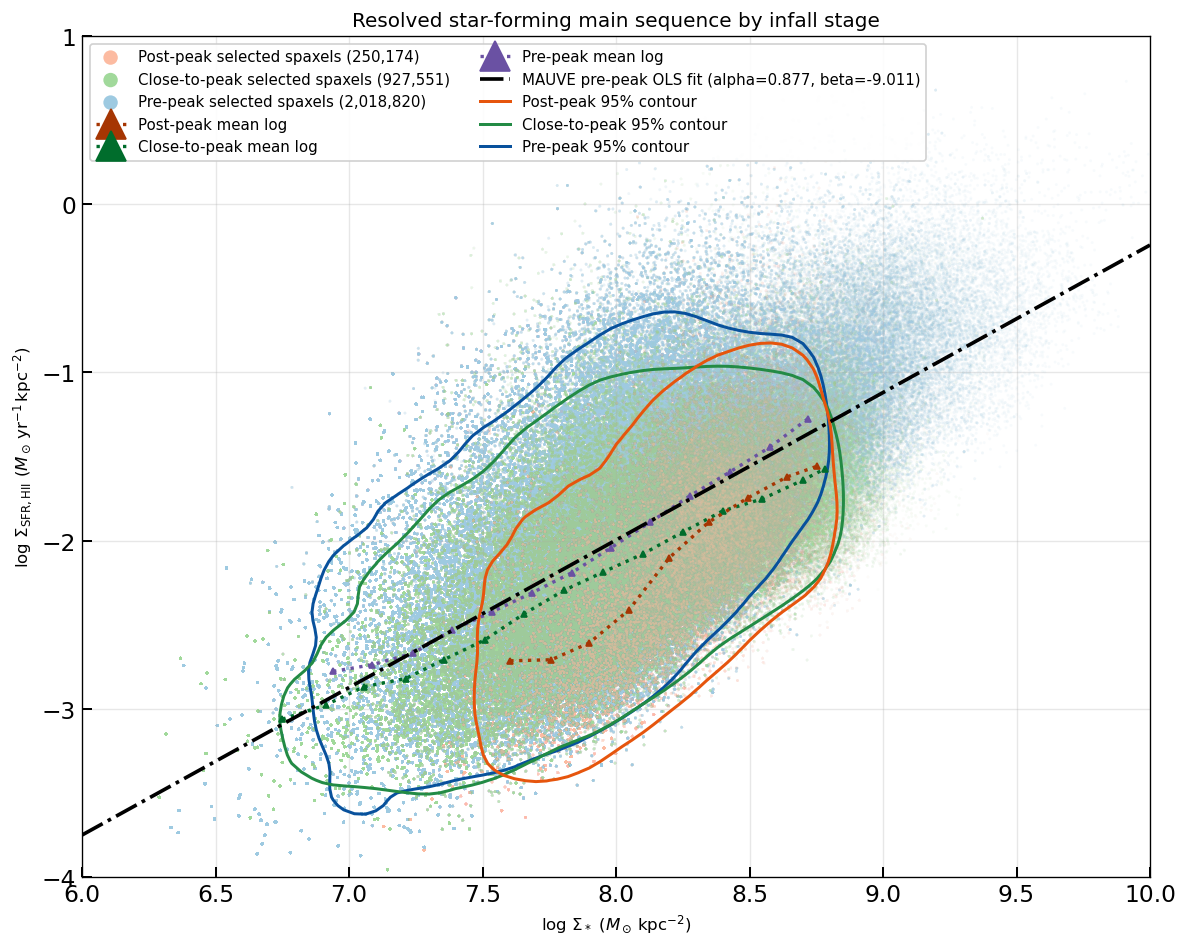


rSFMS sample by infall stage:
  Pre-peak: 2,018,820 spaxels from 11 galaxies
  Close-to-peak: 927,551 spaxels from 10 galaxies
  Post-peak: 250,174 spaxels from 14 galaxies
Selection: HII + EW(Ha)>6 A + intrinsic sigma<45 km/s
Trends: central 95% in stellar mass, 0.15-dex bins, >=50 pixels per bin


In [6]:
# Add pre-peak and post-peak samples using the same selection.
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

RSFMS_STAGE_LABELS = {
    1: "Pre-peak",
    2: "Close-to-peak",
    3: "Post-peak",
}
RSFMS_STAGE_STYLE = {
    1: {
        "scatter": "#9ECAE1",
        "contour": "#08519C",
        "mean_log": "#6A51A3",
        "alpha": 0.08,
        "zorder": 1.0,
    },
    2: {
        "scatter": "#A1D99B",
        "contour": "#238B45",
        "mean_log": "#006D2C",
        "alpha": 0.035,
        "zorder": 2.0,
    },
    3: {
        "scatter": "#FCBBA1",
        "contour": "#E6550D",
        "mean_log": "#A63603",
        "alpha": 0.025,
        "zorder": 3.0,
    },
}
STAGE_CONTOUR_ZORDER = 4.0
STAGE_TREND_ZORDER = 6.0
RSFMS_CONTOUR_BINS = 100
RSFMS_CONTOUR_SMOOTHING = 2.0

stage_log_sigma_m = {
    1: [],
    2: np.asarray(all_log_sigma_m, dtype=float),
    3: [],
}
stage_log_sigma_sfr = {
    1: [],
    2: np.asarray(all_log_sigma_sfr, dtype=float),
    3: [],
}
stage_galaxies = {
    1: [],
    2: list(included_rsfms_galaxies),
    3: [],
}

print("Collecting pre-peak and post-peak selected HII spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage not in (1, 3):
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} {RSFMS_STAGE_LABELS[stage]} selected spaxels")
    if n_spaxels == 0:
        continue
    stage_galaxies[stage].append(galaxy)
    stage_log_sigma_m[stage].extend(log_sigma_m[selected].ravel())
    stage_log_sigma_sfr[stage].extend(log_sigma_sfr[selected].ravel())

for stage in (1, 3):
    stage_log_sigma_m[stage] = np.asarray(stage_log_sigma_m[stage], dtype=float)
    stage_log_sigma_sfr[stage] = np.asarray(stage_log_sigma_sfr[stage], dtype=float)


def plot_stage_95_contour(ax, x, y, *, color, zorder):
    """Plot one 95%-population contour for a stage's central-95% mass sample."""
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    histogram, xedges, yedges = np.histogram2d(
        x[central],
        y[central],
        bins=RSFMS_CONTOUR_BINS,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    smoothed = gaussian_filter(histogram, sigma=RSFMS_CONTOUR_SMOOTHING)
    ranked = np.sort(smoothed[smoothed > 0].ravel())[::-1]
    if ranked.size == 0:
        return None
    cumulative = np.cumsum(ranked)
    level_index = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    level_95 = ranked[min(level_index, ranked.size - 1)]
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    return ax.contour(
        xcenters,
        ycenters,
        smoothed.T,
        levels=[level_95],
        colors=[color],
        linewidths=1.8,
        linestyles="-",
        zorder=zorder,
    )


fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: pre-peak lowest, close-to-peak next, post-peak highest.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x,
        y,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} selected spaxels ({x.size:,})",
    )

# One 95%-population contour per stage, above scatter and below the mean-log trends.
contour_handles = []
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=style["contour"],
        zorder=STAGE_CONTOUR_ZORDER + 0.1 * style["zorder"],
    )
    contour_handles.append(
        Line2D(
            [0], [0], color=style["contour"], linewidth=1.8,
            label=f"{RSFMS_STAGE_LABELS[stage]} 95% contour",
        )
    )

# Mean-log curves are above every scatter and contour layer.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    (
        trend_x,
        mean_log,
        trend_counts,
        trend_limits,
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    ax.plot(
        trend_x,
        mean_log,
        color=style["mean_log"],
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=STAGE_TREND_ZORDER + style["zorder"] + 0.1,
        label=f"{RSFMS_STAGE_LABELS[stage]} mean log",
    )

x_pre_peak_fit = np.linspace(*RSFMS_XRANGE, 200)
y_pre_peak_fit = mauve_pre_peak_alpha * x_pre_peak_fit + mauve_pre_peak_intercept
ax.plot(
    x_pre_peak_fit,
    y_pre_peak_fit,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    zorder=10.0,
    label=(
        f"MAUVE pre-peak OLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.extend(contour_handles)
labels.extend(handle.get_label() for handle in contour_handles)
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in (1, 2, 3):
    print(
        f"  {RSFMS_STAGE_LABELS[stage]}: "
        f"{stage_log_sigma_m[stage].size:,} spaxels from "
        f"{len(stage_galaxies[stage])} galaxies"
    )
print(f"Selection: HII + EW(Ha)>{EW_MIN:g} A + intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s")
print(
    f"Trends: central 95% in stellar mass, {RSFMS_BIN_WIDTH:g}-dex bins, "
    f">={RSFMS_MIN_PIXELS_PER_BIN} pixels per bin"
)


## Individual close-to-peak galaxy rSFMS checks

The pooled close-to-peak relation may suggest an SFR enhancement, but that
signal could be driven by only one or two systems. The following cells therefore
preserve one individual-plot cell for every close-to-peak galaxy in the infall
catalogue. All currently have the required products. They use the same HII +
EW(Hα) > 6 Å + intrinsic Hα dispersion < 45 km s⁻¹ selection, central-95%
stellar-mass range, 0.15-dex bins, ≥50-pixel requirement, 95%-population contour,
and MAUVE pre-peak OLS reference as the combined comparison.


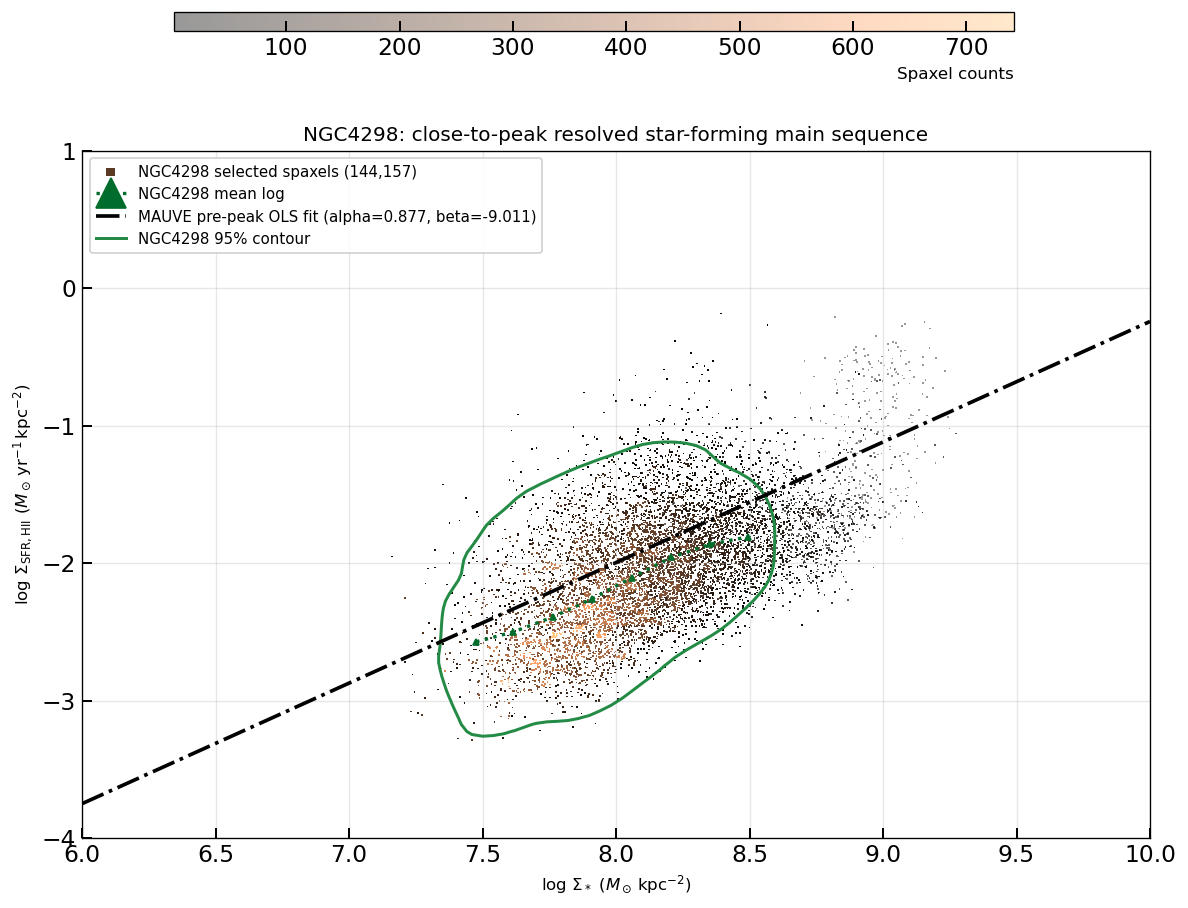

NGC4298: 144,157 selected spaxels
  Central-95% stellar-mass range: 7.386 to 8.567
  Valid trend bins: 8 of 8


In [7]:
CLOSE_TO_PEAK_GALAXIES = [
    "NGC4298",
    "NGC4302",
    "NGC4330",
    "NGC4388",
    "NGC4402",
    "NGC4424",
    "NGC4501",
    "NGC4522",
    "NGC4654",
    "NGC4694",
]

CLOSE_TO_PEAK_AVAILABLE_GALAXIES = list(CLOSE_TO_PEAK_GALAXIES)


def plot_individual_close_to_peak_rsfms(galaxy):
    '''Plot the selected rSFMS, mean-log trend, and 95% contour for one galaxy.'''
    if galaxy not in rsfms_galaxies:
        raise ValueError(f"{galaxy} is not available for the rSFMS analysis")
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a close-to-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no HII+EW+sigma-selected spaxels")

    (
        trend_x,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Match the pooled plot: density-coloured scatter for this galaxy only.
    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]
    scatter = ax.scatter(
        x,
        y,
        c=density,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
        label=f"{galaxy} selected spaxels ({x.size:,})",
    )

    # Keep the single 95%-population contour below the mean-log curve.
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=RSFMS_CONTOUR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    contour_handle = Line2D(
        [0],
        [0],
        color=RSFMS_CONTOUR_COLOR,
        linewidth=1.8,
        label=f"{galaxy} 95% contour",
    )

    ax.plot(
        trend_x,
        mean_log,
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=7.1,
        label=f"{galaxy} mean log",
    )

    x_pre_peak_fit = np.linspace(*RSFMS_XRANGE, 200)
    y_pre_peak_fit = mauve_pre_peak_alpha * x_pre_peak_fit + mauve_pre_peak_intercept
    ax.plot(
        x_pre_peak_fit,
        y_pre_peak_fit,
        color="black",
        linestyle="-.",
        linewidth=2.2,
        zorder=8.0,
        label=(
            f"MAUVE pre-peak OLS fit "
            f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
        ),
    )

    ax.set(
        xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
        ylabel=(
            r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
            r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
        ),
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy}: close-to-peak resolved star-forming main sequence",
    )
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(contour_handle)
    labels.append(contour_handle.get_label())
    legend = ax.legend(
        handles=handles,
        labels=labels,
        loc="upper left",
        ncol=1,
        fontsize=9,
        framealpha=0.9,
        markerscale=5,
    )
    for handle in legend.legend_handles:
        if hasattr(handle, "set_alpha"):
            handle.set_alpha(1.0)

    plt.tight_layout(rect=[0, 0, 1, 0.84])
    colorbar_axis = fig.add_axes([0.15, 0.92, 0.7, 0.02])
    colorbar = plt.colorbar(scatter, cax=colorbar_axis, orientation="horizontal")
    colorbar.set_label("Spaxel counts", loc="right")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_close_to_peak_EW_sigma.png", dpi=600, bbox_inches="tight")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_close_to_peak_EW_sigma.pdf", bbox_inches="tight")
    plt.show()

    print(f"{galaxy}: {x.size:,} selected spaxels")
    print(f"  Central-95% stellar-mass range: {trend_lo:.3f} to {trend_hi:.3f}")
    print(
        f"  Valid trend bins: {np.count_nonzero(trend_counts >= RSFMS_MIN_PIXELS_PER_BIN)} "
        f"of {trend_counts.size}"
    )


plot_individual_close_to_peak_rsfms("NGC4298")


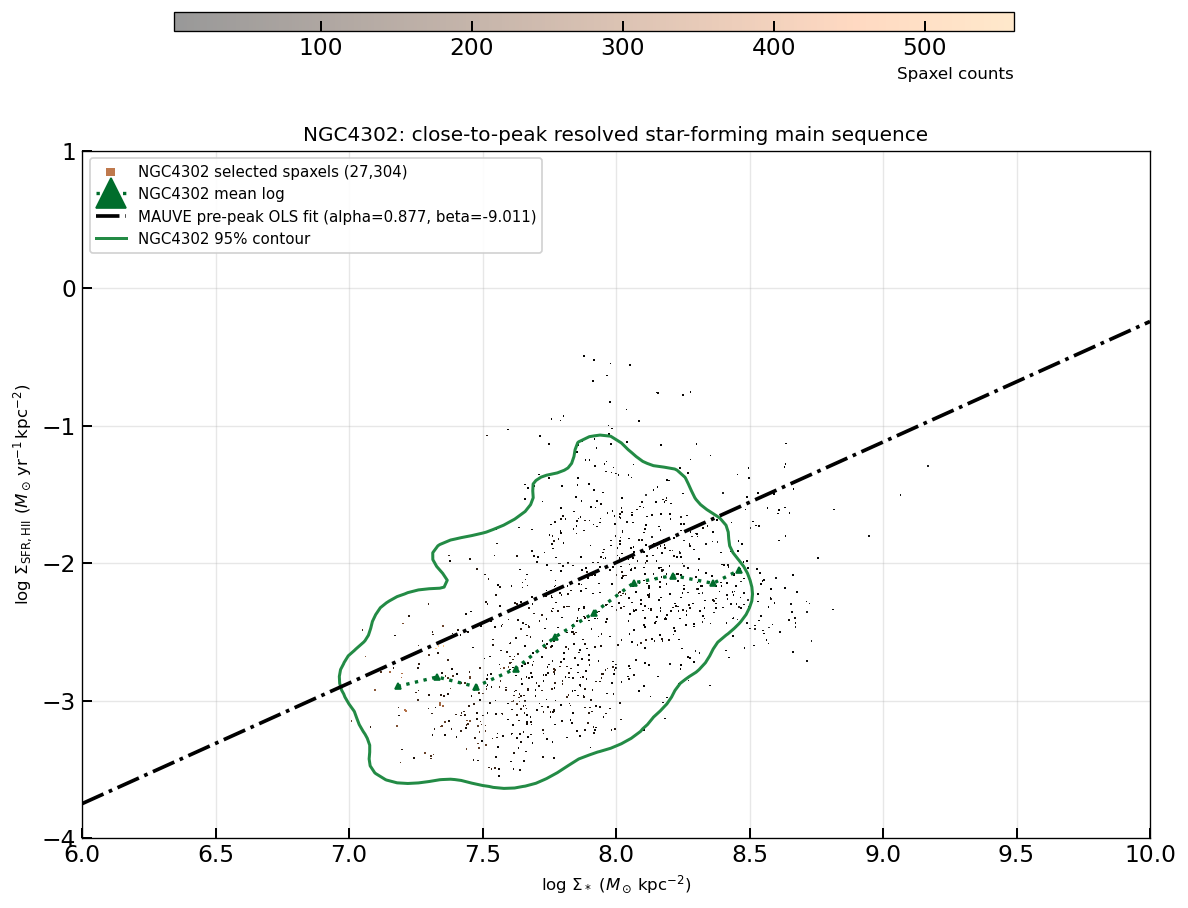

NGC4302: 27,304 selected spaxels
  Central-95% stellar-mass range: 7.096 to 8.470
  Valid trend bins: 10 of 10


In [8]:
plot_individual_close_to_peak_rsfms("NGC4302")


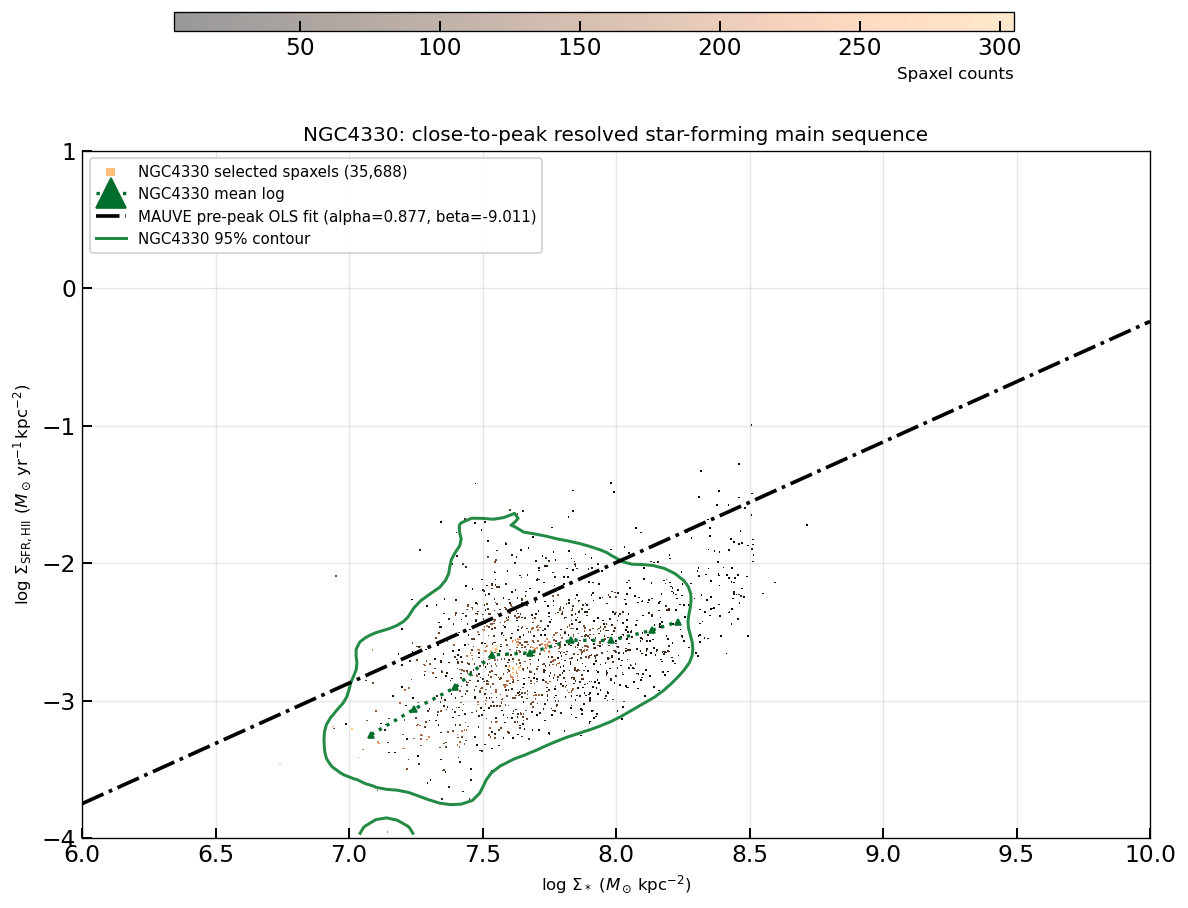

NGC4330: 35,688 selected spaxels
  Central-95% stellar-mass range: 7.011 to 8.254
  Valid trend bins: 9 of 9


In [9]:
plot_individual_close_to_peak_rsfms("NGC4330")


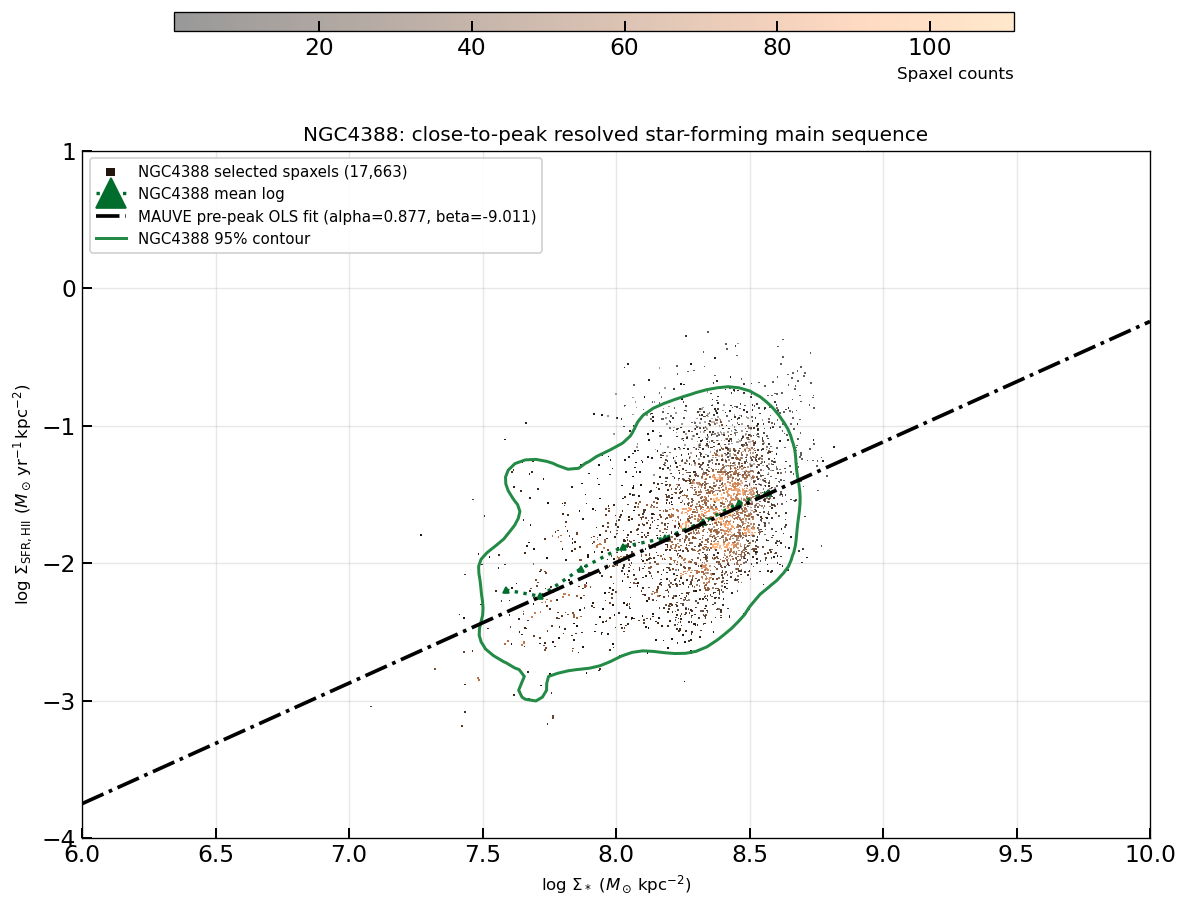

NGC4388: 17,663 selected spaxels
  Central-95% stellar-mass range: 7.498 to 8.587
  Valid trend bins: 8 of 8


In [10]:
plot_individual_close_to_peak_rsfms("NGC4388")


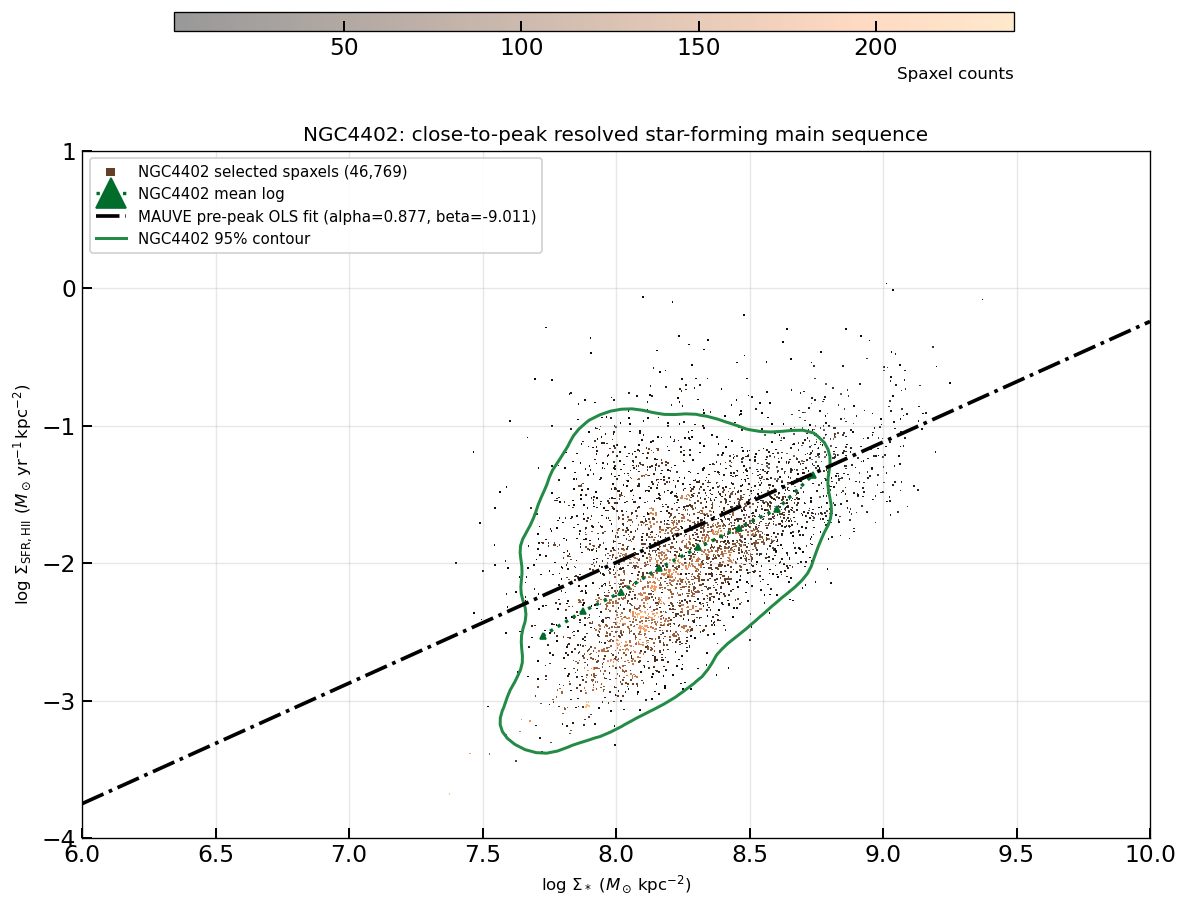

NGC4402: 46,769 selected spaxels
  Central-95% stellar-mass range: 7.640 to 8.785
  Valid trend bins: 8 of 8


In [11]:
plot_individual_close_to_peak_rsfms("NGC4402")


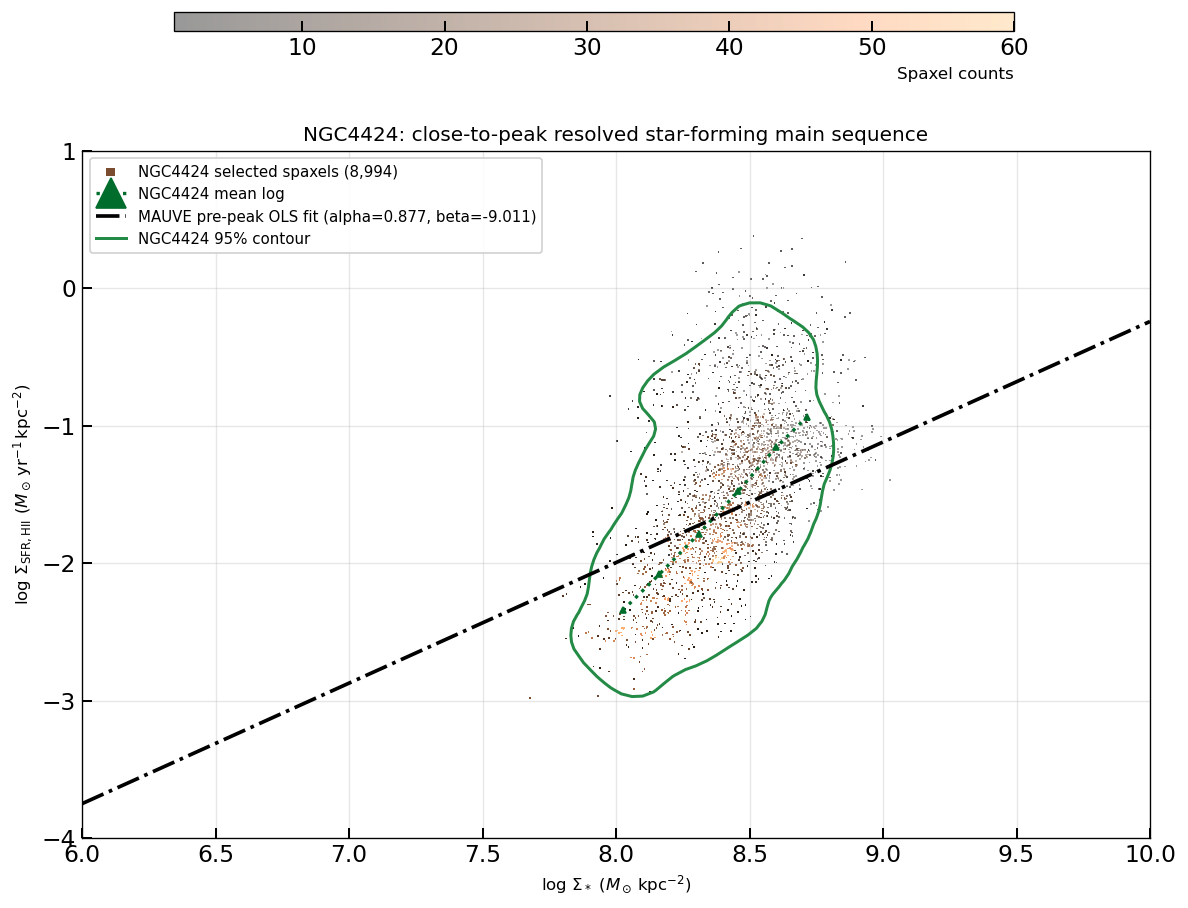

NGC4424: 8,994 selected spaxels
  Central-95% stellar-mass range: 7.937 to 8.748
  Valid trend bins: 6 of 6


In [12]:
plot_individual_close_to_peak_rsfms("NGC4424")


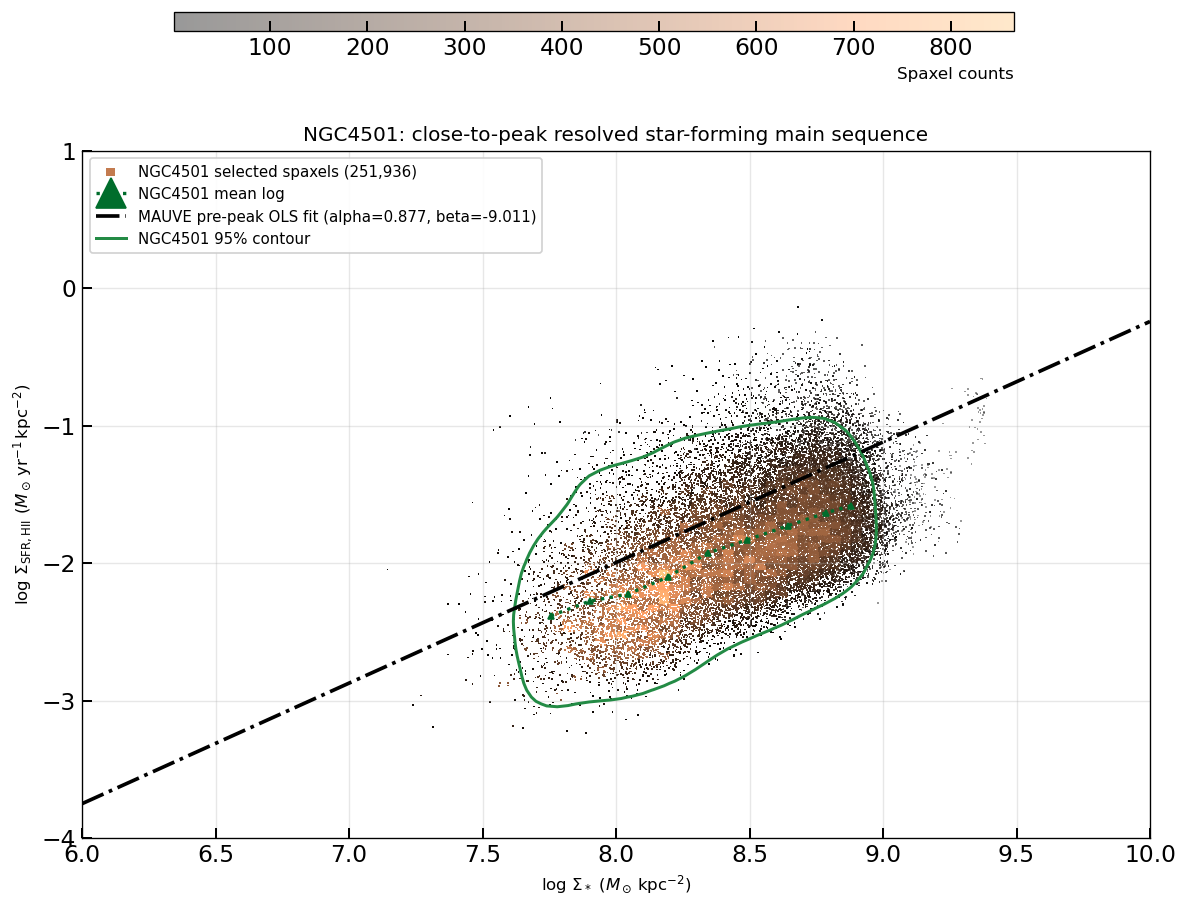

NGC4501: 251,936 selected spaxels
  Central-95% stellar-mass range: 7.669 to 8.894
  Valid trend bins: 9 of 9


In [13]:
plot_individual_close_to_peak_rsfms("NGC4501")


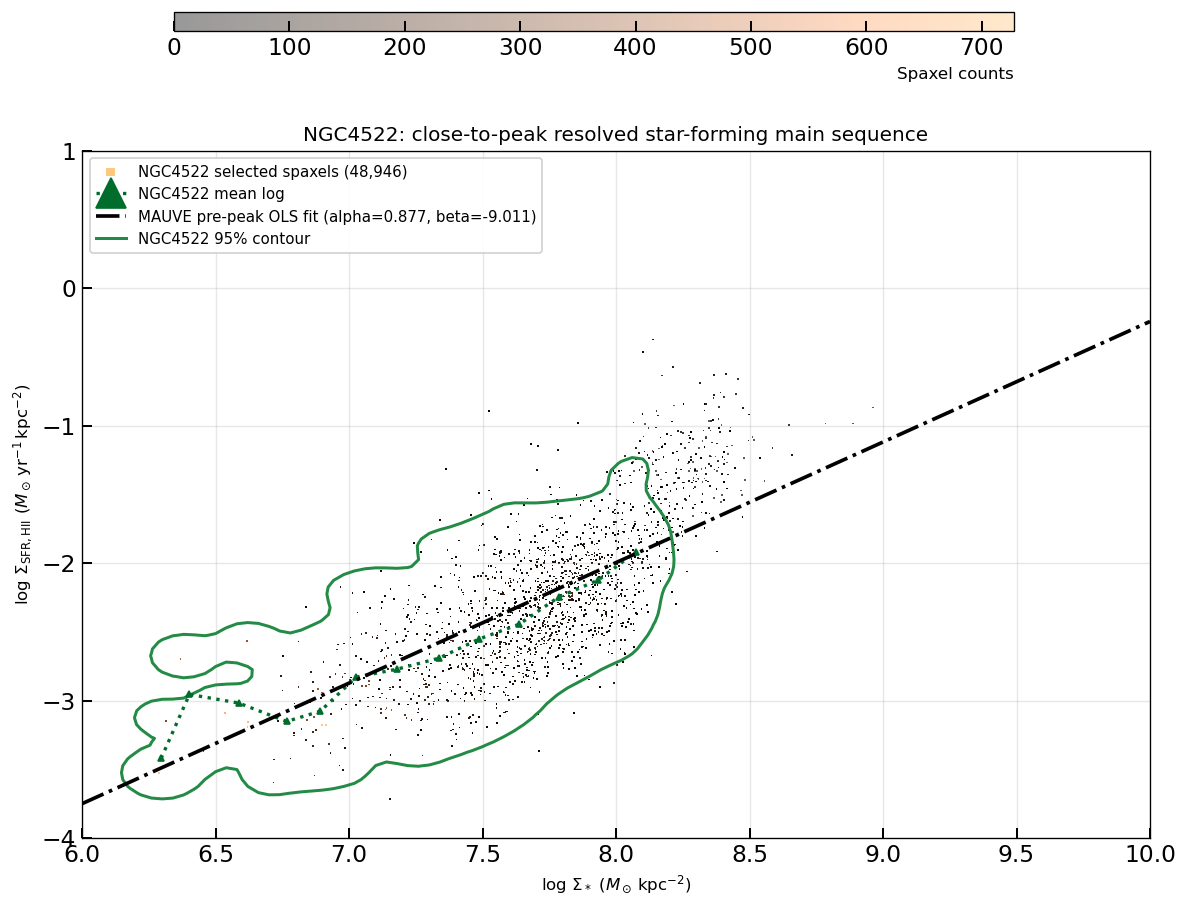

NGC4522: 48,946 selected spaxels
  Central-95% stellar-mass range: 5.763 to 8.155
  Valid trend bins: 14 of 16


In [14]:
plot_individual_close_to_peak_rsfms("NGC4522")


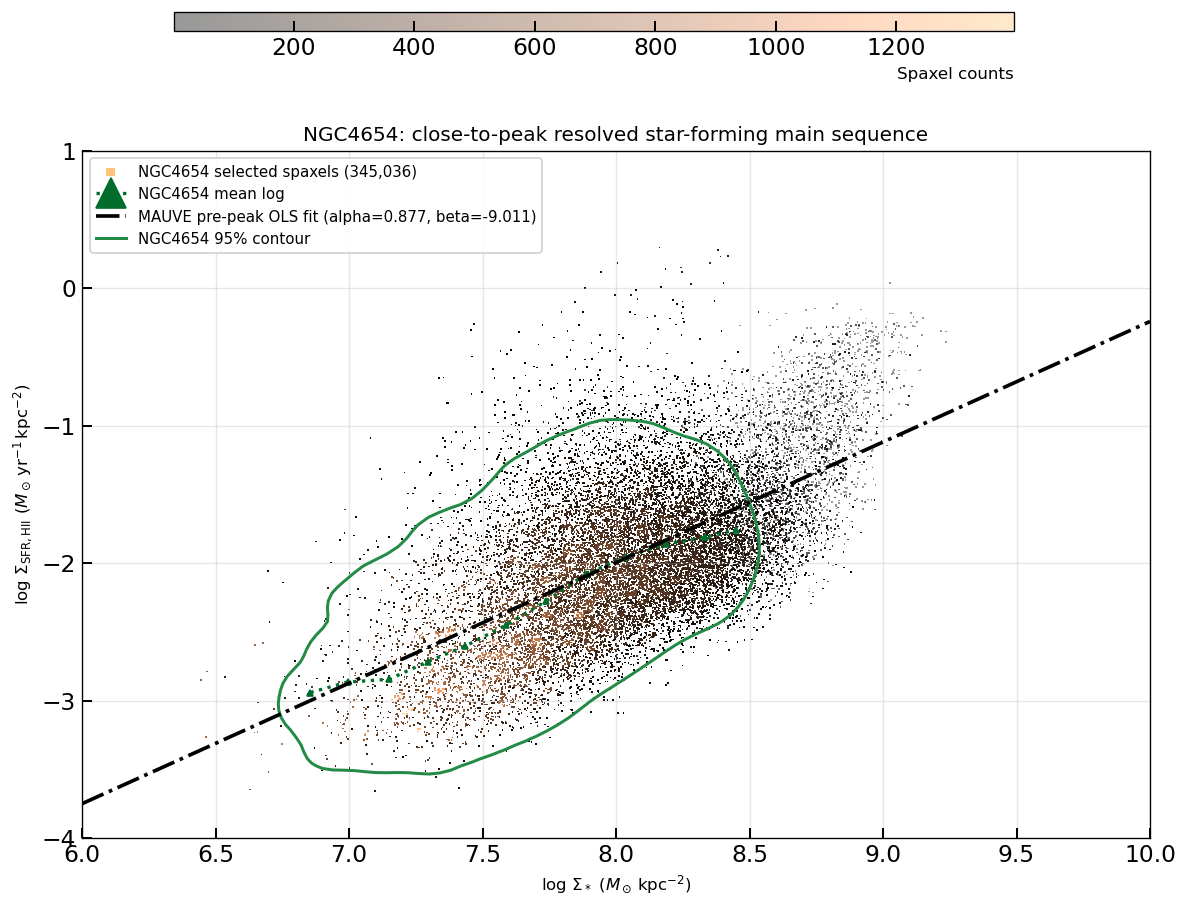

NGC4654: 345,036 selected spaxels
  Central-95% stellar-mass range: 6.765 to 8.490
  Valid trend bins: 12 of 12


In [15]:
plot_individual_close_to_peak_rsfms("NGC4654")


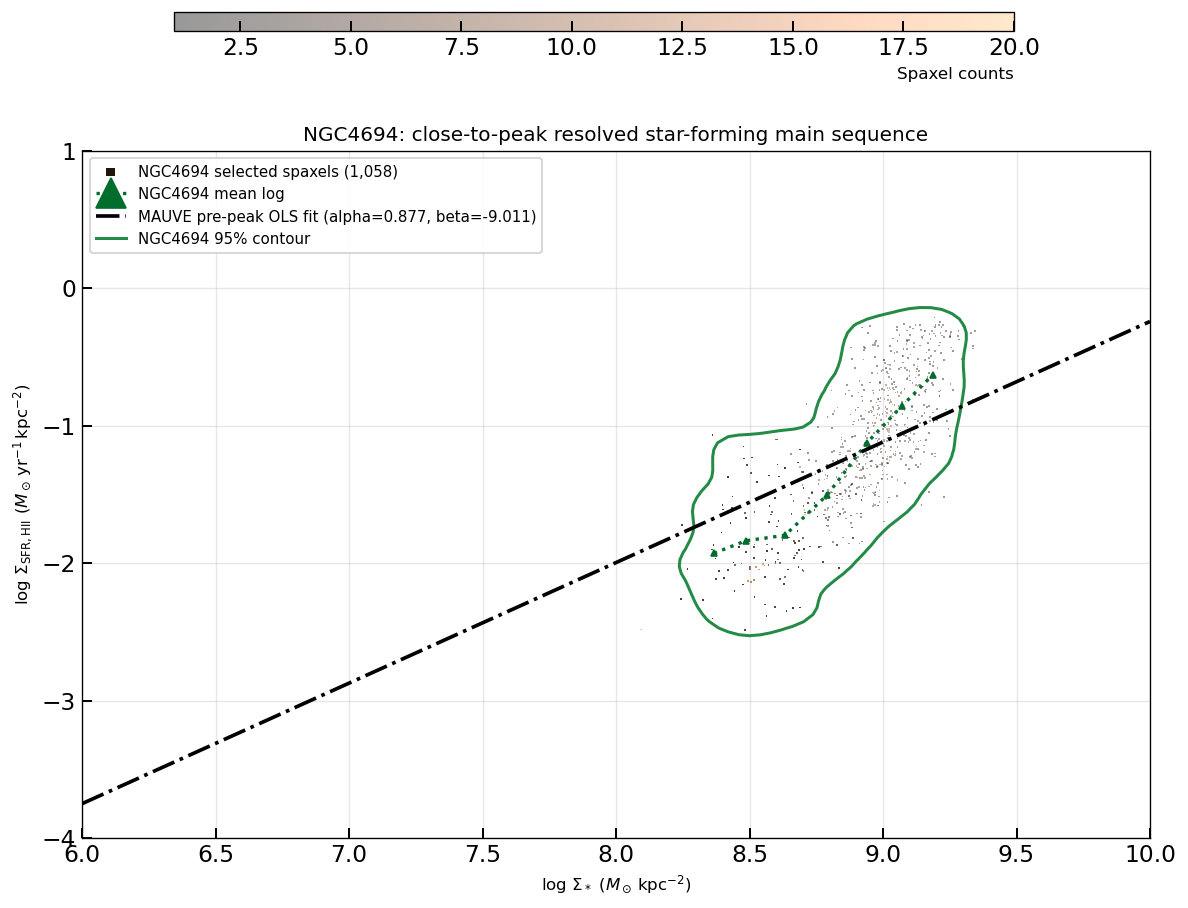

NGC4694: 1,058 selected spaxels
  Central-95% stellar-mass range: 8.256 to 9.227
  Valid trend bins: 7 of 7


In [16]:
plot_individual_close_to_peak_rsfms("NGC4694")


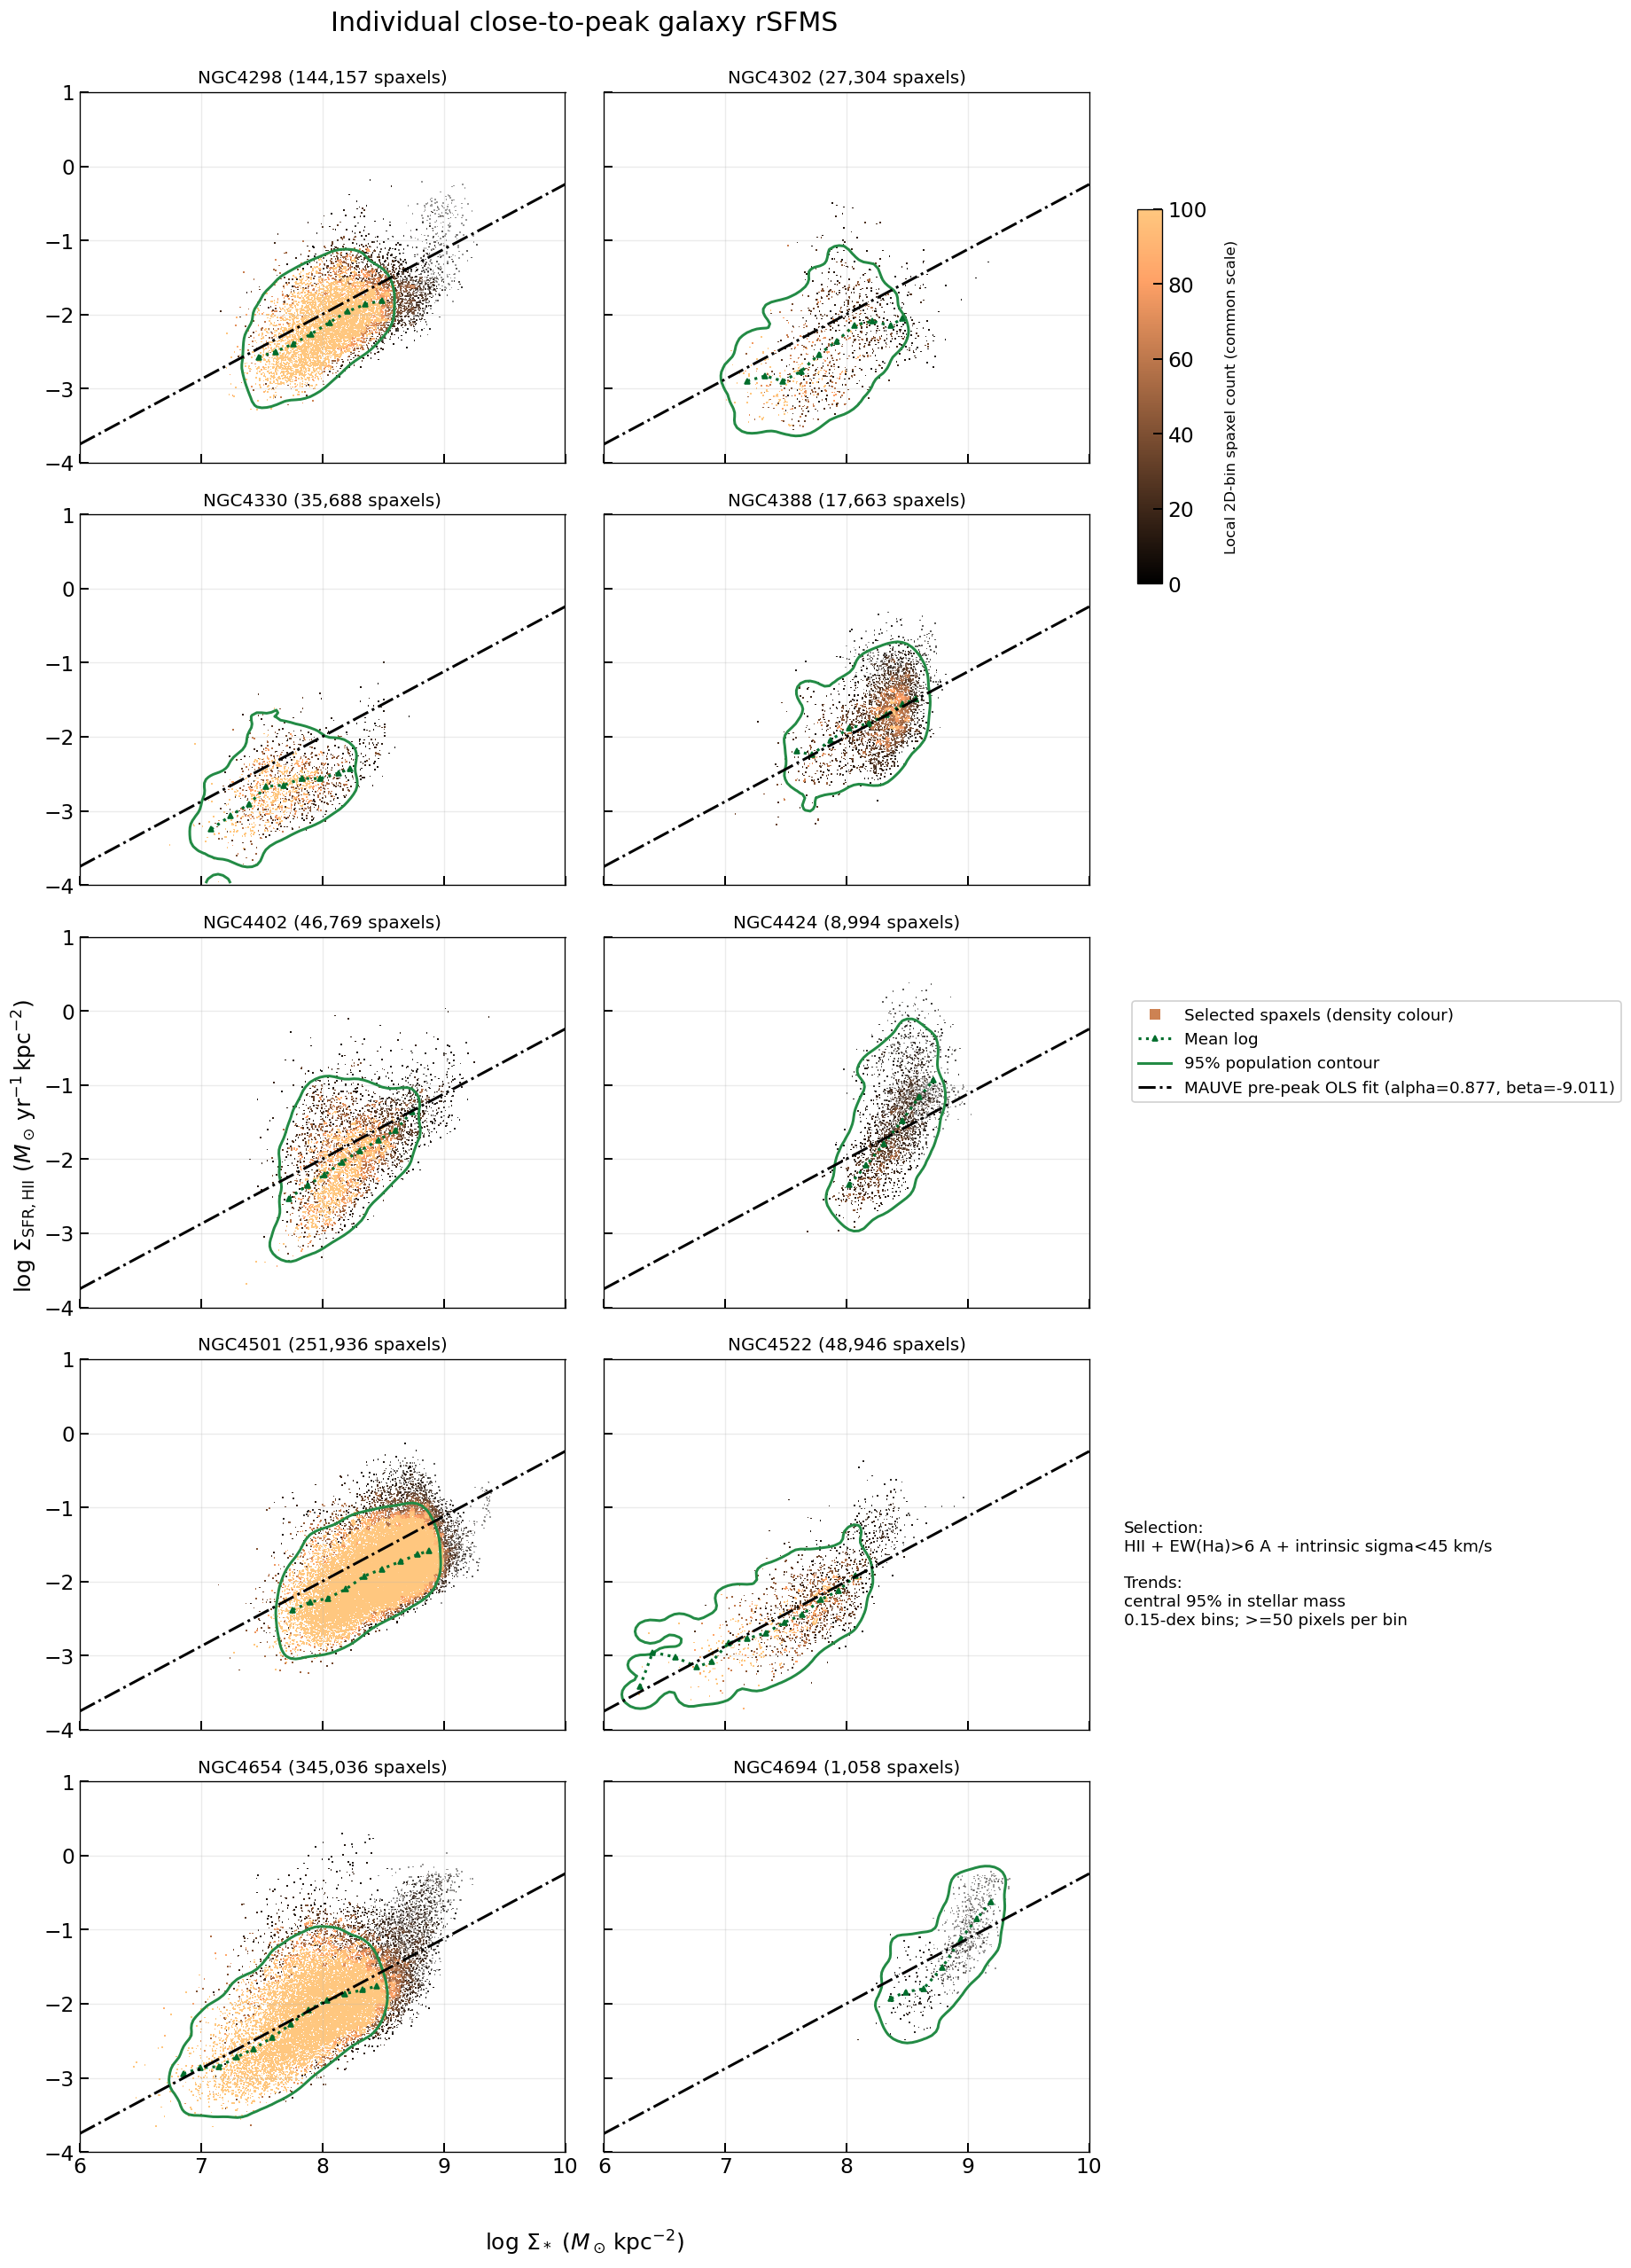

Individual close-to-peak grid summary:
  NGC4298: 144,157 spaxels, central-95% mass=7.386-8.567, valid bins=8
  NGC4302: 27,304 spaxels, central-95% mass=7.096-8.470, valid bins=10
  NGC4330: 35,688 spaxels, central-95% mass=7.011-8.254, valid bins=9
  NGC4388: 17,663 spaxels, central-95% mass=7.498-8.587, valid bins=8
  NGC4402: 46,769 spaxels, central-95% mass=7.640-8.785, valid bins=8
  NGC4424: 8,994 spaxels, central-95% mass=7.937-8.748, valid bins=6
  NGC4501: 251,936 spaxels, central-95% mass=7.669-8.894, valid bins=9
  NGC4522: 48,946 spaxels, central-95% mass=5.763-8.155, valid bins=14
  NGC4654: 345,036 spaxels, central-95% mass=6.765-8.490, valid bins=12
  NGC4694: 1,058 spaxels, central-95% mass=8.256-9.227, valid bins=7


In [17]:
# Five-by-two summary of all currently available close-to-peak galaxies.
from matplotlib.colors import Normalize

grid_galaxies = list(CLOSE_TO_PEAK_AVAILABLE_GALAXIES)
grid_data = {}
GRID_DENSITY_VMAX = 100.0

# Prepare every galaxy first so all panels can share one density normalization.
for galaxy in grid_galaxies:
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a close-to-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no HII+EW+sigma-selected spaxels")

    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]

    (
        trend_x,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    grid_data[galaxy] = {
        "x": x,
        "y": y,
        "density": density,
        "trend_x": trend_x,
        "mean_log": mean_log,
        "trend_counts": trend_counts,
        "trend_limits": (trend_lo, trend_hi),
    }

# Cap the shared colour scale so moderate-density structure remains visible.
grid_density_norm = Normalize(vmin=0.0, vmax=GRID_DENSITY_VMAX, clip=True)
fig, grid_axes_2d = plt.subplots(
    5,
    2,
    figsize=(13, 22),
    sharex=True,
    sharey=True,
    constrained_layout=False,
)
grid_axes = grid_axes_2d.ravel()
fig.subplots_adjust(
    left=0.07,
    right=0.80,
    bottom=0.07,
    top=0.95,
    wspace=0.08,
    hspace=0.14,
)
x_pre_peak_fit_grid = np.linspace(*RSFMS_XRANGE, 200)
y_pre_peak_fit_grid = mauve_pre_peak_alpha * x_pre_peak_fit_grid + mauve_pre_peak_intercept

for ax, galaxy in zip(grid_axes, grid_galaxies):
    data = grid_data[galaxy]
    ax.scatter(
        data["x"],
        data["y"],
        c=data["density"],
        norm=grid_density_norm,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )
    plot_stage_95_contour(
        ax,
        data["x"],
        data["y"],
        color=RSFMS_CONTOUR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    ax.plot(
        data["trend_x"],
        data["mean_log"],
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.3,
        linewidth=1.9,
        zorder=7.1,
    )
    ax.plot(
        x_pre_peak_fit_grid,
        y_pre_peak_fit_grid,
        color="black",
        linestyle="-.",
        linewidth=1.8,
        zorder=8.0,
    )
    ax.set(
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy} ({data['x'].size:,} spaxels)",
    )
    ax.grid(True, alpha=0.25)

# Hide the one unused position in the five-by-two grid.
for ax in grid_axes[len(grid_galaxies):]:
    ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0], marker="s", color="none", markerfacecolor=plt.get_cmap("copper")(0.65),
        markeredgecolor="none", markersize=7, label="Selected spaxels (density colour)",
    ),
    Line2D(
        [0], [0], color=RSFMS_MEAN_LOG_COLOR, linestyle=":", marker="^",
        linewidth=1.9, markersize=4, label="Mean log",
    ),
    Line2D(
        [0], [0], color=RSFMS_CONTOUR_COLOR, linewidth=1.8,
        label="95% population contour",
    ),
    Line2D(
        [0], [0], color="black", linestyle="-.", linewidth=1.8,
        label=(
            f"MAUVE pre-peak OLS fit "
            f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
        ),
    ),
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.825, 0.54),
    ncol=1,
    framealpha=0.9,
    fontsize=11,
)
fig.supxlabel(
    r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    x=0.435,
    y=0.025,
    fontsize=15,
)
fig.supylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    x=0.02,
    fontsize=15,
)
fig.suptitle(
    "Individual close-to-peak galaxy rSFMS",
    x=0.435,
    y=0.985,
    fontsize=18,
)

density_mappable = mpl.cm.ScalarMappable(norm=grid_density_norm, cmap="copper")
density_mappable.set_array([])
density_colorbar_axis = fig.add_axes([0.835, 0.74, 0.018, 0.16])
grid_colorbar = fig.colorbar(
    density_mappable,
    cax=density_colorbar_axis,
    orientation="vertical",
)
grid_colorbar.set_label(
    "Local 2D-bin spaxel count (common scale)",
    rotation=90,
    labelpad=12,
)
fig.text(
    0.825,
    0.34,
    "Selection:\n"
    "HII + EW(Ha)>6 A + intrinsic sigma<45 km/s\n\n"
    "Trends:\n"
    "central 95% in stellar mass\n"
    "0.15-dex bins; >=50 pixels per bin",
    ha="left",
    va="top",
    fontsize=11,
)

# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_close_to_peak_individual_grid.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_close_to_peak_individual_grid.pdf", bbox_inches="tight")
plt.show()

print("Individual close-to-peak grid summary:")
for galaxy in grid_galaxies:
    data = grid_data[galaxy]
    trend_lo, trend_hi = data["trend_limits"]
    valid_bins = int(
        np.count_nonzero(data["trend_counts"] >= RSFMS_MIN_PIXELS_PER_BIN)
    )
    print(
        f"  {galaxy}: {data['x'].size:,} spaxels, "
        f"central-95% mass={trend_lo:.3f}-{trend_hi:.3f}, "
        f"valid bins={valid_bins}"
    )
